# JOLTS-Quits — a quantitative teardown 🔬
### Quits-momentum split returns · Welch *t* + placebo null · the decisive lead/lag cross-correlation · a cyclicals leg · a timing overlay vs buy-and-hold · the release-lag tax · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leading_gauge%3F: Not_supported](https://img.shields.io/badge/Leading_gauge%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that a falling quits rate (1) **predicts** weaker equity/cyclical returns and (2) does so **early** enough to trade. We separate them. The conditional return tilt is *tiny and sign-unstable*; the decisive object is the **lead/lag structure**, which shows quits momentum is **coincident-to-lagging**, not leading — and a ~6-week publication delay plus an overlay that forfeits a third of terminal wealth seals the Tradability axis.

> ⚠️ **Data + lag note.** The quits tape is a hardcoded monthly snapshot of `JTSQUR` (quits rate, Total Nonfarm, SA, percent) — the settled print, **not** the real-time vintage (named on the Signal axis). SPY / XLY / XLP are yfinance daily adjusted close (total-return), month-end sampled. JOLTS publishes reference month t in month **t+2**, so the execution lag is **2 months** (no look-ahead), applied once. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from jolts_quits import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| quits+SPY months:", (0 if F is None else len(F)),
      "| cyclicals:", data.have_cyclicals())

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-12-31', 'end': '2026-05-31', 'months': 306, 'years': 25.4, 'frac_falling': 29, 'h1': (1, 89, 0.62, 0.94, 0.84, 35, 35, -0.4, 0.308), 'h3': (3, 88, 2.1, 2.67, 2.51, 30, 29, -0.4, 0.302), 'h6': (6, 87, 5.65, 4.9, 5.12, 26, 25, 0.36, 0.679), 'h12': (12, 84, 11.39, 10.55, 10.79, 20, 19, 0.27, 0.635), 'leadlag': {-6: 0.046, -5: 0.075, -4: 0.217, -3: 0.195, -2: 0.138, -1: -0.04, 0: 0.056, 1: 0.077, 2: 0.031, 3: 0.03, 4: -0.004, 5: -0.032, 6: -0.059}, 'overlay': (9.7, 0.64, 8.1, 0.69, 7.8, 0.66, 90, 8.7, 6.0), 'cyc': [(1, 89, 0.28, 0.34, -0.1, 0.451), (3, 88, 1.15, 0.92, 0.22, 0.616), (6, 87, 3.15, 1.72, 1.14, 0.917), (12, 84, 6.33, 3.64, 1.66, 0.969)], 'robust': [('k=1', 85, 9.5, 10.8, -0.61, 0.227), ('k=3', 84, 11.4, 10.8, 0.27, 0.635), ('k=6', 97, 13.8, 10.8, 1.33, 0.971), ('thr>0.2pp', 19, 12.4, 10.8, 0.26, 0.66), ('ex-COVID', 80, 11.0, 11.8, -0.37, 0.321)], 'lag': {0: -0.25, 1: 0.1, 2: 0.27}, 'syn': [(0.0, 138, 1.48, 1.03, 1.15, 0.905), (0.04, 138, -1.92, -0.85, -2.64, 0.002)]}


SPY cache present: True | quits+SPY months: 306 | cyclicals: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Best Welch **t = -0.40** (1m); the sign **flips** from −excess at 1–3m to +excess at 6–12m (12m falling **+11.4%** vs base **+10.8%**), down-rate ≈ base everywhere, and a lookback change reverses it. |
| **Tradability** | `MIRAGE` | Cash-on-falling overlay $1→**6.0×** vs buy-hold **8.7×**; Sharpe **0.66 vs 0.64** (a de-risking tie). Beta dialled down, not alpha. |
| **Leading gauge?** | `NOT SUPPORTED` | Peak lead/lag correlation at **L = −4** (quits lag the market by a quarter); flat at positive leads — then published ~6 weeks late. |

> 💡 In plain words: the equity market *is* a leading indicator of the economy, so a labour series that co-moves with equity weakness need not lead it. Quits momentum lines up with a market move already a quarter old — the 'early-warning' is the market's own lead, reflected back, and then delayed by the JOLTS release schedule.

## 1 · The claim, steelmanned

Let $q_t$ be the JOLTS quits rate (percent) and $m_t = q_t - q_{t-3}$ its 3-month change (percentage points). Quits are **FALLING** at $t$ when $m_t < 0$. With the JOLTS publication delay the month-$t$ print is public in month $t+2$, so we act at the close of $t+2$ (a 2-month execution lag) and define forward return $r_{t+2\to t+2+H}$.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{falling}] < \mathbb{E}[r]$ — a *negative* excess over the base rate, at **every** horizon.
- **H₂ (leads).** The strongest positive quits↔return correlation sits at a **positive** lead (quits move first; falling quits → lower returns ⇒ $\rho(L{>}0) > 0$).
- **H₃ (deployable).** A cash-on-falling overlay beats buy-and-hold net of costs.

We find **H₁ rejected** (tiny, insignificant, and *sign-unstable* across horizon), **H₂ rejected** (peak positive corr at $L=-4$), **H₃ rejected** (overlay forfeits a third of terminal wealth). The folklore is right only where it's uninformative (quits and the cycle co-move) and wrong exactly where it would pay (a *leading*, *tradable* edge).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{falling}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{falling}}/k + s^2_{\text{all}}/N\,}}.$$

But a significant $\widehat{\Delta}$ would **still not** establish *leading*: a coincident or lagging series can co-move with forward returns through cycle autocorrelation. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(m_t,\ r_{t+L\to t+L+1})$. A genuine early-warning peaks (positively) at $L>0$. If $\arg\max_L \rho(L) < 0$, quits **follow** the market — and the entire 'early' thesis collapses regardless of the conditional mean. On top of that sits an *institutional* constraint the other macro studies don't face: the **2-month JOLTS publication delay**, which taxes any residual lead before you can act.

## 3 · How we'd know — the protocol

- **Quits tape.** Monthly `JTSQUR` (percent, SA), hardcoded snapshot, 2000-12→2026-05 (306 months). Settled print, not real-time vintage (named on the axis).
- **Signal.** $m_t = q_t-q_{t-3}$; FALLING when $m_t<0$.
- **Forward returns.** Enter at the close **2 months after** the reference month (the JOLTS release lag — no look-ahead), hold $H\in\{1,3,6,12\}$ months; drop horizons that overrun the tape. Run on **SPY** and on a **cyclical-minus-defensive** (XLY−XLP) long-short.
- **Null #1 (Welch t).** Falling-set mean vs the unconditional mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \le \text{falling mean}]$ (as bearish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$ — *where* do quits line up?
- **Tradability.** Cash-when-falling overlay, 2-month lag, 10 bps one-way per switch (turnover one-way × NAV), excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* quits→returns link: `edge=0` must not fake bearish significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — tiny, insignificant, and sign-unstable

Falling-quits forward mean with $\pm$ standard error against the unconditional base rate (dashed). Below base at 1–3m, **above** base at 6–12m — every gap inside its own error bar.

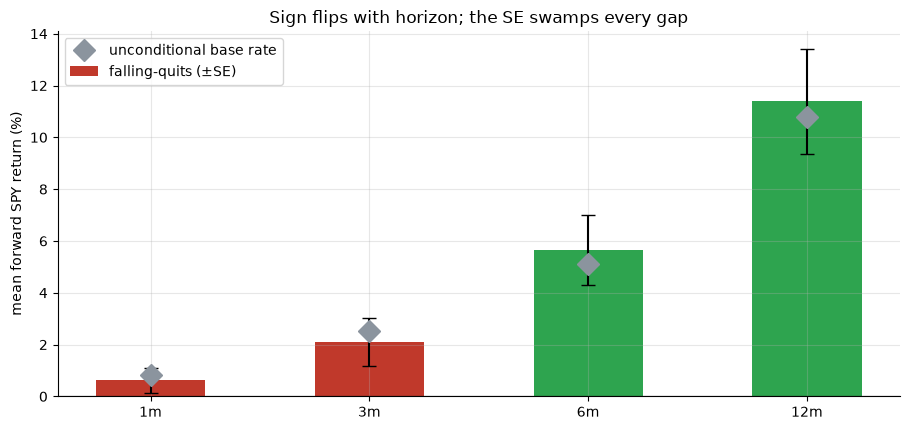

Welch t by horizon: {'1m': -0.4, '3m': -0.4, '6m': 0.36, '12m': 0.27}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['falling_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        d,_u,_a = st.split_returns(F, m); ses.append(d.std(ddof=1)/np.sqrt(len(d)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]; ses = [.012,.02,.03,.045]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if c<b else GREEN for c,b in zip(cm,bm)]
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=cols, width=.5, label='falling-quits (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Sign flips with horizon; the SE swamps every gap'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 1m the falling-quits mean is **+0.6%** vs base **+0.8%** (right sign, **t = -0.40**); at 12m it's **+11.4%** vs **+10.8%** — *above* base, **t = +0.27**. H₁ is **rejected**: not just insignificant but *directionally incoherent*. A real gauge doesn't change its mind about the sign between quarter one and year one.

### 4b · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(m_t, r_{t+L\to t+L+1})$. Positive bars left of zero = quits **lag** the market; a real leading gauge would peak on the **right** (quits lead).

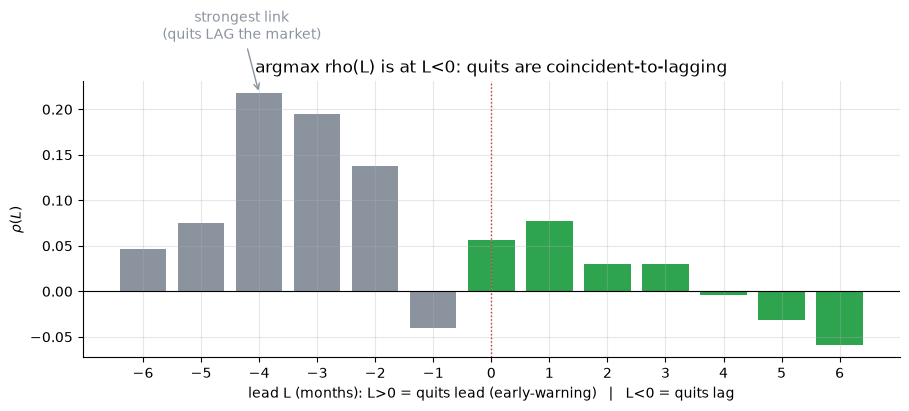

argmax at L=-4 (rho=+0.22); rho at +1 month = +0.08


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREY if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=RED, lw=1, ls=':')
imax = int(np.nanargmax(cs))
ax.annotate('strongest link\n(quits LAG the market)', xy=(Ls[imax], cs[imax]),
            xytext=(Ls[imax]-0.3, cs[imax]+0.06), ha='center', color=GREY,
            arrowprops=dict(arrowstyle='->', color=GREY))
ax.set_xlabel('lead L (months): L>0 = quits lead (early-warning)   |   L<0 = quits lag')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('argmax rho(L) is at L<0: quits are coincident-to-lagging')
plt.tight_layout(); plt.show()
print(f'argmax at L={Ls[imax]} (rho={cs[imax]:+.2f}); rho at +1 month = {cs[Ls.index(1)]:+.2f}')

> 💡 In plain words: $\arg\max_L \rho(L) = -4$. The quits signal correlates most with a market move **a quarter in its past**; at the positive leads a genuine early-warning needs, $\rho \approx +0.05$. **H₂ rejected.** The equity market leads the economy; quits trail both — the 'early-warning' is the market's lead, reflected. This is the load-bearing result, independent of the conditional-mean significance, and it survives before the release lag is even charged.

### 4c · The cyclicals leg — the claim's own target goes the wrong way

The believers single out cyclicals. So we run the split on a monthly-rebalanced **XLY − XLP** (discretionary minus staples) long-short — the risk-appetite tape. Falling quits should make it *negative*; instead it's *more positive* than base.

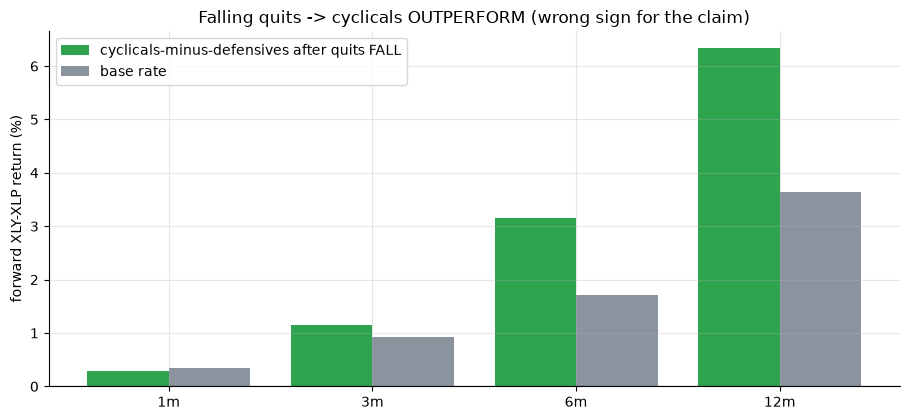

cyc 12m: falling 6.3% vs base 3.6% t= 1.66


In [4]:
if HAVE_REAL and 'cyc' in F.columns:
    hs2 = [1,3,6,12]; cf=[]; cb=[]; ct=[]
    for m in hs2:
        s = st.summarize(F, m, price='cyc'); cf.append(s['falling_mean']*100); cb.append(s['base_mean']*100); ct.append(s['t'])
else:
    hs2 = [1,3,6,12]; cf=[c[2] for c in R['cyc']]; cb=[c[3] for c in R['cyc']]; ct=[c[4] for c in R['cyc']]
x = np.arange(len(hs2))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cf, .4, color=GREEN, label='cyclicals-minus-defensives after quits FALL')
ax.bar(x+.2, cb, .4, color=GREY, label='base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs2]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('forward XLY-XLP return (%)'); ax.legend()
ax.set_title('Falling quits -> cyclicals OUTPERFORM (wrong sign for the claim)')
plt.tight_layout(); plt.show()
print('cyc 12m: falling', f'{cf[-1]:.1f}%', 'vs base', f'{cb[-1]:.1f}%', 't=', round(ct[-1],2))

> 💡 In plain words: at 12m the cyclical spread is **+6.3%** after falling quits vs **+3.6%** base (**t = +1.66**) — the *opposite* of the claim, and still insignificant. Cyclicals lead the recovery that the lagging quits reading is sinking into, so 'sell cyclicals when quits fall' is, if anything, a fade of the next up-leg.

### 4d · Tradability — the cash-on-falling overlay forfeits a third of the pot

Hold SPY when quits rise, cash when falling (2-month lag, 10 bps/switch). Annualised mean, Sharpe, and terminal wealth vs buy-and-hold.

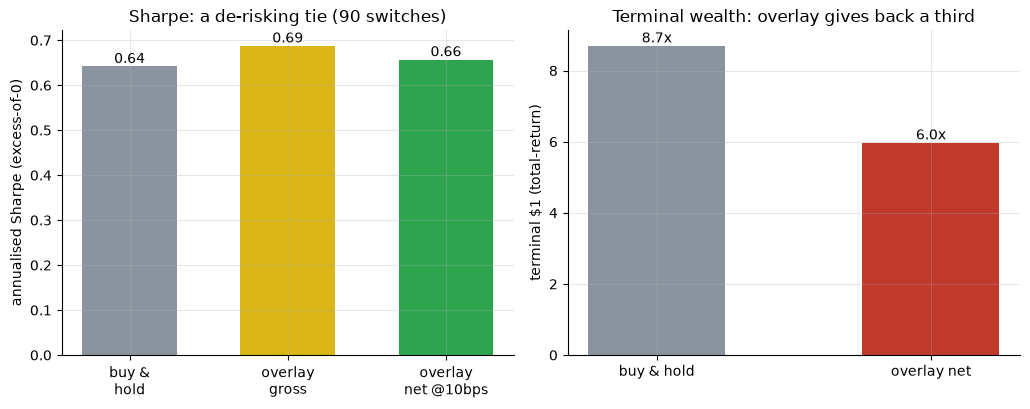

net overlay 7.8%/yr (Sharpe 0.66, 6.0x) vs buy-hold 9.7%/yr (Sharpe 0.64, 8.7x)


In [5]:
if HAVE_REAL:
    import pandas as pd
    o = st.timing_overlay(F, cost_bps=10.0)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    g_m, g_s = o['overlay_gross_mean']*100, o['overlay_gross_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; nsw=o['n_switches']
    falling = st.falling_mask(F); pos=(~falling).astype(float).shift(2); rr=F['spy'].pct_change()
    dfp = pd.DataFrame({'r':rr,'pos':pos}).dropna(); sw=dfp['pos'].diff().abs().fillna(0)
    ov=(dfp['pos']*dfp['r']-sw*10/1e4); bh_T=(1+dfp['r']).cumprod().iloc[-1]; ov_T=(1+ov).cumprod().iloc[-1]
else:
    bh_m, bh_s = R['overlay'][0], R['overlay'][1]; g_m,g_s = R['overlay'][2],R['overlay'][3]
    n_m, n_s = R['overlay'][4], R['overlay'][5]; nsw=R['overlay'][6]; bh_T=R['overlay'][7]; ov_T=R['overlay'][8]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold', 'overlay\ngross', 'overlay\nnet @10bps']
a1.bar(labels, [bh_s, g_s, n_s], color=[GREY, AMBER, GREEN], width=.6)
for i,v in enumerate([bh_s,g_s,n_s]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised Sharpe (excess-of-0)'); a1.set_title(f'Sharpe: a de-risking tie ({nsw} switches)')
a2.bar(['buy & hold','overlay net'], [bh_T, ov_T], color=[GREY, RED], width=.5)
for i,v in enumerate([bh_T,ov_T]): a2.annotate(f'{v:.1f}x',(i,v),ha='center',va='bottom')
a2.set_ylabel('terminal $1 (total-return)'); a2.set_title('Terminal wealth: overlay gives back a third')
plt.tight_layout(); plt.show()
print(f'net overlay {n_m:.1f}%/yr (Sharpe {n_s:.2f}, {ov_T:.1f}x) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f}, {bh_T:.1f}x)')

> 💡 In plain words: the overlay's Sharpe (**0.66**) barely tops buy-and-hold's (**0.64**) — a rounding-tie — and buys it only by sitting in cash ~29% of months, forfeiting **~2 pts/yr** and ending at **6.0× vs 8.7×**. That Sharpe wobble is **de-risking**, reproducible by just holding less SPY at zero research cost. **H₃ rejected.** `MIRAGE`.

### 4e · Robustness + the publication-delay tax

Vary the momentum window $k$, the threshold, and drop 2020–2021 — then check the execution lag. The 12-month *t* is a coin-flip of the window, and even the (untradable) look-ahead lag is near zero, so there's no edge for the delay to erode.

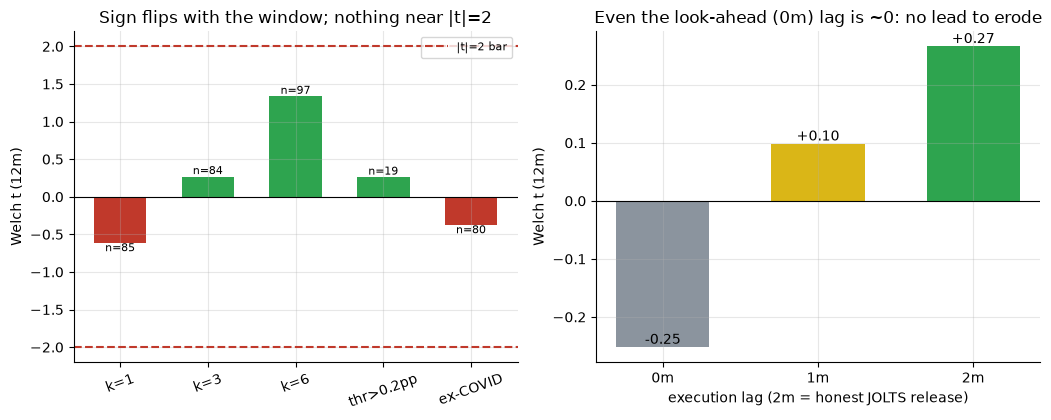

robustness (label,n,t): [('k=1', 85, -0.61), ('k=3', 84, 0.27), ('k=6', 97, 1.33), ('thr>0.2pp', 19, 0.26), ('ex-COVID', 80, -0.37)]
lag sensitivity (t): {0: -0.25, 1: 0.1, 2: 0.27}


In [6]:
if HAVE_REAL:
    rob = []
    for k in (1,3,6):
        s = st.summarize(F, 12, k=k); rob.append((f'k={k}', s['n_falling'], s['t']))
    s = st.summarize(F, 12, thresh=0.2); rob.append(('thr>0.2pp', s['n_falling'], s['t']))
    F2 = F[(F.index < '2020-01-01') | (F.index >= '2022-01-01')]
    s = st.summarize(F2, 12); rob.append(('ex-COVID', s['n_falling'], s['t']))
    lags = {lg: st.summarize(F, 12, lag=lg)['t'] for lg in (0,1,2)}
else:
    rob = [(r[0], r[1], r[4]) for r in R['robust']]; lags = R['lag']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
labels = [r[0] for r in rob]; tt = [r[2] for r in rob]; nn = [r[1] for r in rob]
cols = [RED if t<0 else GREEN for t in tt]
a1.bar(labels, tt, color=cols, width=.6); a1.axhline(0, c='k', lw=.8)
a1.axhline(-2, ls='--', c=RED, label='|t|=2 bar'); a1.axhline(2, ls='--', c=RED)
for i,(t,k) in enumerate(zip(tt,nn)): a1.annotate(f'n={k}',(i,t),ha='center',va='bottom' if t>=0 else 'top', fontsize=8)
a1.set_ylabel('Welch t (12m)'); a1.set_title('Sign flips with the window; nothing near |t|=2'); a1.legend(fontsize=8)
a1.tick_params(axis='x', labelrotation=20)
lk = sorted(lags); a2.bar([f'{l}m' for l in lk], [lags[l] for l in lk], color=[GREY,AMBER,GREEN], width=.6)
for i,l in enumerate(lk): a2.annotate(f'{lags[l]:+.2f}',(i,lags[l]),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('Welch t (12m)')
a2.set_title('Even the look-ahead (0m) lag is ~0: no lead to erode')
a2.set_xlabel('execution lag (2m = honest JOLTS release)')
plt.tight_layout(); plt.show()
print('robustness (label,n,t):', [(r[0], r[1], round(r[2],2)) for r in rob])
print('lag sensitivity (t):', {k: round(v,2) for k,v in sorted(lags.items())})

> 💡 In plain words: the slow (k=6) filter turns *positive* (**t=+1.33**), the fast (k=1) filter *negative* (**t=-0.61**), ex-COVID is **t=-0.37** — a sign you can choose. And the *look-ahead* 0-month lag is only **t=-0.25**, so there was never a timing edge for the 6-week delay to tax. Real only where you cherry-pick, useless everywhere it would pay.

### 4f · Faithful-engine control — we know the truth here

A deterministic monthly series with a *planted* link (falling quits momentum at $t$ depresses the $t{+}1$ return by `edge`). With `edge=0` the bearish test must stay flat; with a large `edge` it must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

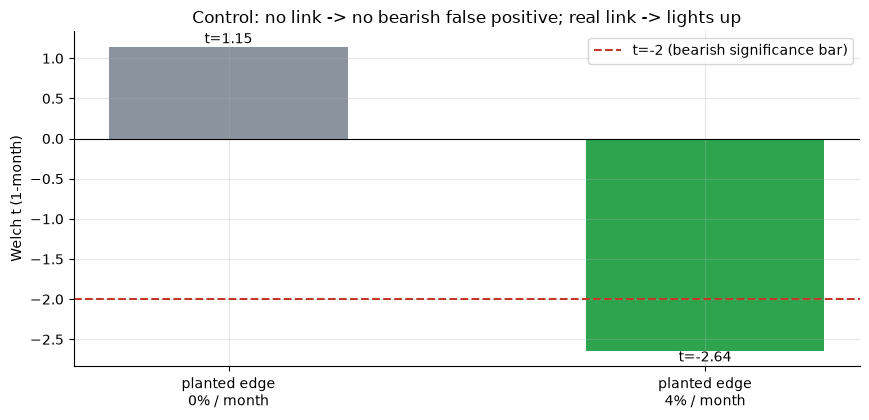

planted +0%/mo: n_fall=138 falling=1.48% base=1.03% t=1.15 p=0.905
planted +4%/mo: n_fall=138 falling=-1.92% base=-0.85% t=-2.64 p=0.002


In [7]:
res = []
for edge in (0.0, 0.04):
    syn = data.synthetic_quits(n_months=300, edge=edge, seed=755)
    s = st.summarize(syn, 1, k=3, lag=1)
    res.append((edge, s['n_falling'], s['falling_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(-2, ls='--', c=RED, label='t=-2 (bearish significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('Welch t (1-month)'); ax.set_title('Control: no link -> no bearish false positive; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/mo: n_fall={k} falling={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the bearish test shows no false positive (**t = +1.15**, placebo **p = 0.91** — the opposite of significant-and-negative); a **+4%/month** planted link drives **t = -2.64** (**p = 0.002**). So the machinery is honest — the real-tape near-zero *t* is a *genuine* absent edge, not a broken test. The engine *can* bank a real quits→returns link; the real tape just doesn't carry one.

## 5 · The verdict

- **Signal `NONE`** — best Welch **t = -0.40**; the excess **flips sign** from −0.2pp at 1m to **++0.6pp** at 12m, the down-rate matches base at every horizon, and the window choice reverses the sign. The named cyclicals leg goes the **wrong** way. Not a certified signal — noise.
- **Tradability `MIRAGE`** — the cash-on-falling overlay ends at **6.0×** vs buy-hold **8.7×** on $1 (**+7.8%/yr** vs **+9.7%/yr**); the Sharpe **0.66 vs 0.64** tie is de-risking, not alpha. Nothing to allocate to.
- **Leading gauge? `NOT SUPPORTED`** — $\arg\max_L \rho(L) = -4$ months: quits momentum is **coincident-to-lagging**, not leading; flat at positive leads, and then published ~6 weeks late. The equity market is the leading indicator; quits echo it. The defining word — *early* — is the part the data rejects.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a genuine few-basis-point tilt. Two structural facts defeat it. **(1) The release lag.** JOLTS reports reference month t in month t+2, so the *fastest* honest action is already ~6 weeks stale — and since even the look-ahead (0-lag) test is ≈0, there is no lead to be late for. **(2) The wrong target.** The overlay is out of the market ~29% of the time, forfeiting a third of terminal wealth for a Sharpe wobble, while the claim's favourite trade — short cyclicals on falling quits — has the **wrong sign** (cyclicals lead the recovery the quits reading is lagging into). No lag, threshold, or cost assumption rescues a coincident series, published late, masquerading as a leading one.

## 7 · Going further

- **The sibling.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/): *rising* claims as an early-warning, same hardcoded-snapshot + SPY method — another coincident labour echo, not a lead.
- **Companion macro nowcasts.** [Study 384 — ISM-PMI-Regime](../384-ism-pmi-regime/), [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) — does any celebrated macro gauge time equities?
- **Sharper identification.** Use **real-time vintages** (ALFRED) to kill any revision look-ahead, or run a proper VAR / Granger test on the weekly-equivalent series; the coincident-to-lagging structure and the publication delay are robust to all of these — smoothing a coincident series differently can't manufacture a lead.

*The reproducible core is offline and deterministic; the quits input is an explicit frozen snapshot. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*